# Classification with Logistic Regression


Predicting customer retention (AT&T, T-Mobile, Verizon)

# Import libraries and datasets

In [96]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, auc
import matplotlib.pyplot as plt
np.random.seed(2025)

In [97]:
churn = pd.read_csv('customerchurn.csv')
print(churn.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            7032 non-null   int64  
 1   MonthlyCharges   7032 non-null   float64
 2   SeniorCitizen    7032 non-null   int64  
 3   PaymentMethod    7032 non-null   object 
 4   InternetService  7032 non-null   object 
 5   tenure           7032 non-null   int64  
 6   Contract         7032 non-null   object 
dtypes: float64(1), int64(3), object(3)
memory usage: 384.7+ KB
None


In [98]:
display(churn)

,Churn,MonthlyCharges,SeniorCitizen,PaymentMethod,InternetService,tenure,Contract
0,0,29.85,0,Electronic check,DSL,1,Month-to-month
1,0,56.95,0,Mailed check,DSL,34,One year
2,1,53.85,0,Mailed check,DSL,2,Month-to-month
3,0,42.30,0,Bank transfer,DSL,45,One year
4,1,70.70,0,Electronic check,Fiber optic,2,Month-to-month
...,...,...,...,...,...,...,...
7027,0,84.80,0,Mailed check,DSL,24,One year
7028,0,103.20,0,Credit card,Fiber optic,72,One year
7029,0,29.60,0,Electronic check,DSL,11,Month-to-month
7030,1,74.40,1,Mailed check,Fiber optic,4,Month-to-month


# Predicting Customer Churn

Monthly Charges vs Churn

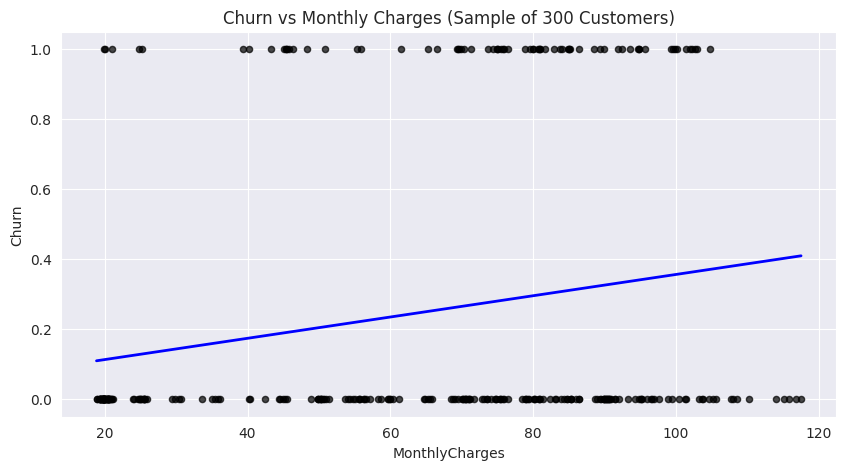

In [99]:
# Creating linear regression graph on MonthlyCharges vs Churn with subset of 300 customers
subset = churn.sample(n=300, random_state=42)

# Set ggplot-like style (gray background with grid)
sns.set_style("darkgrid")
plt.figure(figsize=(10, 5))
sns.regplot(
    x="MonthlyCharges", y="Churn", data=subset,
    ci=None,
    scatter_kws={"s": 20, "alpha": 0.7, "color": "black"},
    line_kws={"color": "blue", "linewidth": 2}
)

plt.title("Churn vs Monthly Charges (Sample of 300 Customers)")
plt.show()

Payment Methods vs Churn

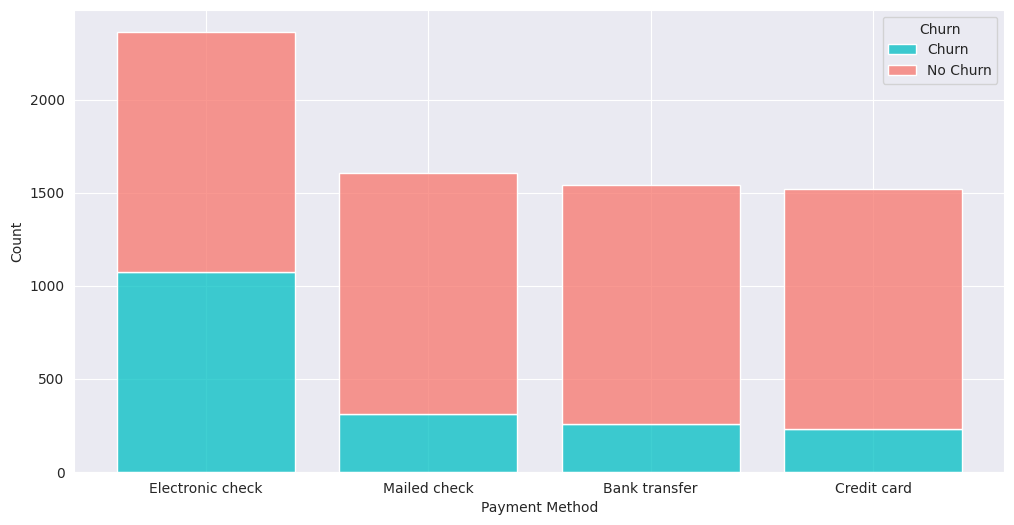

In [100]:
sns.set_style("darkgrid")

plt.figure(figsize=(12, 6))
ax =sns.histplot(
    data=churn,
    x="PaymentMethod",
    hue="Churn",
    multiple="stack",
    shrink=0.8,
    palette ={0: "#F8766D", 1: "#00BFC4"},
    hue_order=[0, 1]
)

plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.legend(title="Churn", labels = ["Churn", "No Churn"])
plt.show()

Contract vs Churn

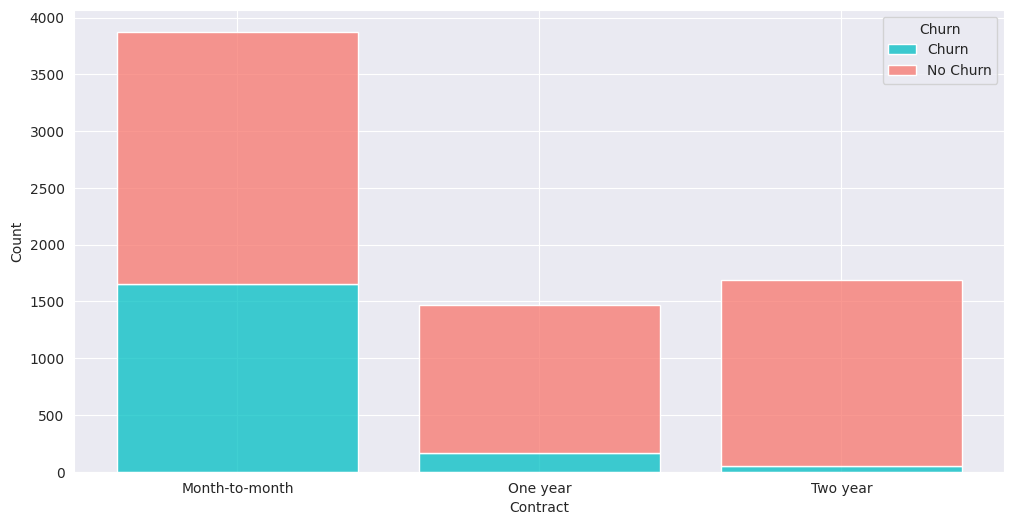

In [101]:
sns.set_style("darkgrid")

plt.figure(figsize=(12, 6))
ax =sns.histplot(
    data=churn,
    x="Contract",
    hue="Churn",
    multiple="stack",
    shrink=0.8,
    palette ={0: "#F8766D", 1: "#00BFC4"},
    hue_order=[0, 1]
)

plt.xlabel("Contract")
plt.ylabel("Count")
plt.legend(title="Churn", labels = ["Churn", "No Churn"])
plt.show()

Split data into 30% testing and 70% training

In [102]:
X = churn.drop("Churn", axis=1)   # all columns except Churn
y = churn["Churn"]                # target column

# Split: 70% training, 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=2025, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 4922
Test size: 2110


In [103]:
display(churn)

,Churn,MonthlyCharges,SeniorCitizen,PaymentMethod,InternetService,tenure,Contract
0,0,29.85,0,Electronic check,DSL,1,Month-to-month
1,0,56.95,0,Mailed check,DSL,34,One year
2,1,53.85,0,Mailed check,DSL,2,Month-to-month
3,0,42.30,0,Bank transfer,DSL,45,One year
4,1,70.70,0,Electronic check,Fiber optic,2,Month-to-month
...,...,...,...,...,...,...,...
7027,0,84.80,0,Mailed check,DSL,24,One year
7028,0,103.20,0,Credit card,Fiber optic,72,One year
7029,0,29.60,0,Electronic check,DSL,11,Month-to-month
7030,1,74.40,1,Mailed check,Fiber optic,4,Month-to-month


In [104]:
display(X_train.sort_index())

,MonthlyCharges,SeniorCitizen,PaymentMethod,InternetService,tenure,Contract
0,29.85,0,Electronic check,DSL,1,Month-to-month
1,56.95,0,Mailed check,DSL,34,One year
2,53.85,0,Mailed check,DSL,2,Month-to-month
4,70.70,0,Electronic check,Fiber optic,2,Month-to-month
5,99.65,0,Electronic check,Fiber optic,8,Month-to-month
...,...,...,...,...,...,...
7024,78.70,0,Bank transfer,Fiber optic,19,Month-to-month
7025,60.65,0,Electronic check,DSL,12,One year
7026,21.15,0,Bank transfer,No,72,Two year
7028,103.20,0,Credit card,Fiber optic,72,One year


In [105]:
display(X_test.sort_index())

,MonthlyCharges,SeniorCitizen,PaymentMethod,InternetService,tenure,Contract
3,42.30,0,Bank transfer,DSL,45,One year
6,89.10,0,Credit card,Fiber optic,22,Month-to-month
13,103.70,0,Bank transfer,Fiber optic,49,Month-to-month
15,113.25,0,Credit card,Fiber optic,69,Two year
18,55.20,0,Credit card,DSL,10,Month-to-month
...,...,...,...,...,...,...
7019,20.05,0,Mailed check,No,2,Month-to-month
7020,60.00,1,Credit card,DSL,55,One year
7027,84.80,0,Mailed check,DSL,24,One year
7029,29.60,0,Electronic check,DSL,11,Month-to-month


# Customer Retention Model

In [106]:
# Run this code cell
def significance_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    elif p < 0.1:
        return '.'
    else:
        return ''

def print_summary_with_stars(model):
    """
    Print a comprehensive summary for GLM logistic regression models with significance stars.
    """
    # Create coefficients table first (needed to measure width)
    coef_data = {
        'Coef': model.params,
        'Std Err': model.bse,
        'z': model.tvalues,
        'P>|z|': model.pvalues,
        '[0.025': model.conf_int()[0],
        '0.975]': model.conf_int()[1]
    }
    coef_table = pd.DataFrame(coef_data)
    coef_table['Signif'] = coef_table['P>|z|'].apply(significance_stars)

    # Round numeric columns
    numeric_columns = ['Coef', 'Std Err', 'z', 'P>|z|', '[0.025', '0.975]']
    for col in numeric_columns:
        coef_table[col] = coef_table[col].round(4)

    # Figure out max width from the table and some static text
    table_str = coef_table.to_string()
    max_width = max(len(line) for line in table_str.split("\n"))
    # Also compare with titles/labels
    other_texts = [
        "Logistic Regression Results",
        "Significance codes: '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1"
    ]
    max_width = max(max_width, *(len(t) for t in other_texts))
    bar_len = max_width + 5  # add buffer

    def line(char="="):
        return char * bar_len

    # Print header
    print(line("="))
    print("Logistic Regression Results")
    print(line("="))

    # print(f"Model Family: {model.family.__class__.__name__}")
    # print(f"Link Function: {model.family.link.__class__.__name__}")
    # print(f"Method: Maximum Likelihood Estimation (MLE)")
    print(f"No. Observations: {int(model.nobs)}")
    print(f"Df Model: {int(model.df_model)}")
    print(f"Df Residuals: {int(model.df_resid)}")

    print(line("="))
    print("Coefficients:")
    print(line("-"))
    print(table_str)
    print(line("="))
    print("Significance codes: '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1")
    print(line("="))

In [107]:
# Recreate full train/test dataframes
churn_train = pd.concat([X_train, y_train], axis=1)
churn_test = pd.concat([X_test, y_test], axis=1)
display(churn_train.head())

# Build initial model with all variables
feature_names = X_train.columns.tolist()
model = smf.glm(formula = f"Churn ~ {' + '.join(feature_names)}", data = churn_train, family = sm.families.Binomial()).fit()
# model = smf.logit(formula = "Churn ~ MonthlyCharges + SeniorCitizen + PaymentMethod + InternetService + tenure + Contract", data = churn_train).fit()
model.summary()

,MonthlyCharges,SeniorCitizen,PaymentMethod,InternetService,tenure,Contract,Churn
1854,85.35,0,Electronic check,Fiber optic,52,Month-to-month,1
2203,100.80,1,Electronic check,Fiber optic,1,Month-to-month,1
5631,79.60,0,Electronic check,Fiber optic,1,Month-to-month,1
4317,67.45,0,Electronic check,DSL,40,Month-to-month,0
3534,108.65,0,Bank transfer,Fiber optic,72,Two year,0


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  Churn   No. Observations:                 4922
Model:                            GLM   Df Residuals:                     4911
Model Family:                Binomial   Df Model:                           10
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2094.3
Date:                Sat, 05 Sep 2026   Deviance:                       4188.7
Time:                        13:17:13   Pearson chi2:                 4.95e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.2643
Covariance Type:            nonrobust                                         
=====================================================================================================
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                            -0.7589      0.210     -3.616      0.000      -1.170      -0.348
PaymentMethod[T.Credit card]         -0.1080      0.134     -0.808      0.419      -0.370       0.154
PaymentMethod[T.Electronic check]     0.4069      0.111      3.674      0.000       0.190       0.624
PaymentMethod[T.Mailed check]        -0.0688      0.135     -0.509      0.611      -0.334       0.196
InternetService[T.Fiber optic]        0.9723      0.154      6.319      0.000       0.671       1.274
InternetService[T.No]                -0.7436      0.183     -4.069      0.000      -1.102      -0.385
Contract[T.One year]                 -0.7605      0.123     -6.207      0.000      -1.001      -0.520
Contract[T.Two year]                 -1.5812      0.207     -7.653      0.000      -1.986      -1.176
MonthlyCharges                        0.0045      0.004      1.258      0.208      -0.003       0.012
SeniorCitizen                         0.3029      0.098      3.105      0.002       0.112       0.494
tenure                               -0.0313      0.003    -12.350      0.000      -0.036      -0.026
=====================================================================================================
"""

In [108]:
print_summary_with_stars(model)

Logistic Regression Results
No. Observations: 4922
Df Model: 10
Df Residuals: 4911
Coefficients:
-----------------------------------------------------------------------------------------------
                                     Coef  Std Err        z   P>|z|  [0.025  0.975] Signif
Intercept                         -0.7589   0.2099  -3.6162  0.0003 -1.1702 -0.3476    ***
PaymentMethod[T.Credit card]      -0.1080   0.1337  -0.8078  0.4192 -0.3701  0.1541       
PaymentMethod[T.Electronic check]  0.4069   0.1108   3.6735  0.0002  0.1898  0.6240    ***
PaymentMethod[T.Mailed check]     -0.0688   0.1353  -0.5085  0.6111 -0.3339  0.1963       
InternetService[T.Fiber optic]     0.9723   0.1539   6.3186  0.0000  0.6707  1.2739    ***
InternetService[T.No]             -0.7436   0.1828  -4.0688  0.0000 -1.1019 -0.3854    ***
Contract[T.One year]              -0.7605   0.1225  -6.2073  0.0000 -1.0006 -0.5204    ***
Contract[T.Two year]              -1.5812   0.2066  -7.6534  0.0000 -1.9861 -1.

$$\alpha = \beta_0 + \beta_1 \cdot x_{i,1} + \beta_2 \cdot x_{i,2} + \cdots + \beta_k \cdot x_{i,k}\\   
= -0.7589 + 0.0045 \cdot 94.51 + 0.3029 \cdot 1.0 + \cdots + -1.5812 \cdot 1.0 = -2.399$$


Since `MonthlyCharges` is not significant (no significance stars) let us remove it and create another model without it

In [109]:
feature_names = [col for col in X_train.columns.tolist() if col != "MonthlyCharges"]
formula = f"Churn ~ {' + '.join(feature_names)}"

model2 = smf.glm(formula=formula, data=churn_train, family=sm.families.Binomial()).fit()

print_summary_with_stars(model2)

Logistic Regression Results
No. Observations: 4922
Df Model: 9
Df Residuals: 4912
Coefficients:
-----------------------------------------------------------------------------------------------
                                     Coef  Std Err        z   P>|z|  [0.025  0.975] Signif
Intercept                         -0.5452   0.1226  -4.4454  0.0000 -0.7856 -0.3048    ***
PaymentMethod[T.Credit card]      -0.1095   0.1337  -0.8193  0.4126 -0.3716  0.1525       
PaymentMethod[T.Electronic check]  0.4098   0.1107   3.7014  0.0002  0.1928  0.6269    ***
PaymentMethod[T.Mailed check]     -0.0705   0.1352  -0.5214  0.6021 -0.3356  0.1946       
InternetService[T.Fiber optic]     1.1292   0.0912  12.3883  0.0000  0.9505  1.3079    ***
InternetService[T.No]             -0.8825   0.1452  -6.0780  0.0000 -1.1671 -0.5980    ***
Contract[T.One year]              -0.7404   0.1214  -6.0993  0.0000 -0.9783 -0.5025    ***
Contract[T.Two year]              -1.5527   0.2053  -7.5647  0.0000 -1.9550 -1.1

Since only Electronic Check is important in the `PaymentMethod` variable, let us create a new variable called `ElectronicCheck` which is 1 if True and 0 otherwise.

In [110]:
churn_train_ec = churn_train.copy()
churn_train_ec["ElectronicCheck"] = (churn_train_ec["PaymentMethod"] == "Electronic check").astype(int)
churn_train_ec = churn_train_ec.drop(columns=["PaymentMethod"])
print(churn_train_ec.head(10))

      MonthlyCharges  SeniorCitizen InternetService  tenure        Contract  \
1854           85.35              0     Fiber optic      52  Month-to-month   
2203          100.80              1     Fiber optic       1  Month-to-month   
5631           79.60              0     Fiber optic       1  Month-to-month   
4317           67.45              0             DSL      40  Month-to-month   
3534          108.65              0     Fiber optic      72        Two year   
5300           20.25              0              No      61        Two year   
2717           18.95              0              No      32        Two year   
5004           20.10              0              No      12  Month-to-month   
3701           19.90              0              No      69        Two year   
5897           78.95              1     Fiber optic      14  Month-to-month   

      Churn  ElectronicCheck  
1854      1                1  
2203      1                1  
5631      1                1  
4317  

In [111]:
formula = f"Churn ~ SeniorCitizen + InternetService + tenure + ElectronicCheck + Contract"
model3 = smf.glm(formula=formula, data=churn_train_ec, family=sm.families.Binomial()).fit()
print_summary_with_stars(model3)

Logistic Regression Results
No. Observations: 4922
Df Model: 7
Df Residuals: 4914
Coefficients:
--------------------------------------------------------------------------------------------
                                  Coef  Std Err        z   P>|z|  [0.025  0.975] Signif
Intercept                      -0.6083   0.0849  -7.1682  0.0000 -0.7747 -0.4420    ***
InternetService[T.Fiber optic]  1.1323   0.0904  12.5278  0.0000  0.9551  1.3094    ***
InternetService[T.No]          -0.8851   0.1435  -6.1669  0.0000 -1.1664 -0.6038    ***
Contract[T.One year]           -0.7421   0.1214  -6.1145  0.0000 -0.9800 -0.5042    ***
Contract[T.Two year]           -1.5539   0.2052  -7.5711  0.0000 -1.9561 -1.1516    ***
SeniorCitizen                   0.3031   0.0975   3.1083  0.0019  0.1120  0.4942     **
tenure                         -0.0301   0.0023 -12.9011  0.0000 -0.0347 -0.0255    ***
ElectronicCheck                 0.4686   0.0809   5.7926  0.0000  0.3100  0.6272    ***
Significance codes:

# Confusion Matrix

In [112]:
churn_test_ec = churn_test.copy()
churn_test_ec["ElectronicCheck"] = (churn_test_ec["PaymentMethod"] == "Electronic check").astype(int)
pred = model3.predict(churn_test_ec)
churn_test_ec['Pr(Yi=1)'] = pred
print(pred)

790     0.035980
5923    0.698891
5232    0.073273
5308    0.312393
2740    0.779974
          ...   
1096    0.185972
5451    0.016777
2672    0.599535
80      0.723609
1774    0.717548
Length: 2110, dtype: float64


In [113]:
y_pred = (pred>= 0.33).astype(int)
churn_test_ec['ChurnRisk'] = y_pred

# Make a copy so we don’t overwrite original
churn_test_display = churn_test_ec.copy()

# Reorder columns: put 'Churn' and 'Churn-Risk' at the front
cols = ["Churn", "SeniorCitizen"] + [c for c in churn_test_display.columns if c not in ["Churn", "SeniorCitizen"]]
churn_test_display = churn_test_display[cols]

display(churn_test_display.sort_index())


,Churn,SeniorCitizen,MonthlyCharges,PaymentMethod,InternetService,tenure,Contract,ElectronicCheck,Pr(Yi=1),ChurnRisk
3,0,0,42.30,Bank transfer,DSL,45,One year,0,0.062676,0
6,0,0,89.10,Credit card,Fiber optic,22,Month-to-month,0,0.465475,1
13,1,0,103.70,Bank transfer,Fiber optic,49,Month-to-month,0,0.278666,0
15,0,0,113.25,Credit card,Fiber optic,69,Two year,0,0.042819,0
18,1,0,55.20,Credit card,DSL,10,Month-to-month,0,0.287129,0
...,...,...,...,...,...,...,...,...,...,...
7019,0,0,20.05,Mailed check,No,2,Month-to-month,0,0.174558,0
7020,0,1,60.00,Credit card,DSL,55,One year,0,0.062797,0
7027,0,0,84.80,Mailed check,DSL,24,One year,0,0.111760,0
7029,0,0,29.60,Electronic check,DSL,11,Month-to-month,1,0.384410,1


In [114]:
conf_matrix = confusion_matrix(churn_test_ec['Churn'], churn_test_ec['ChurnRisk'])
conf_matrix

array([[1217,  332],
       [ 147,  414]])

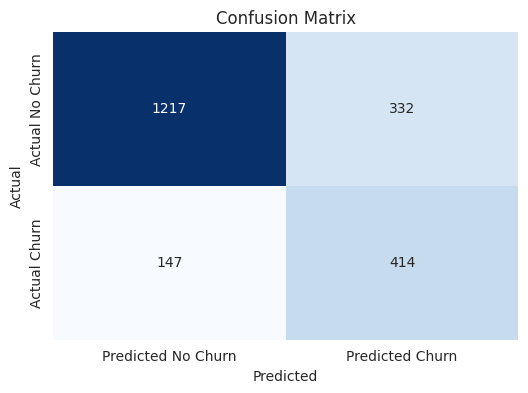

In [115]:
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix,
            annot=True,
            fmt="d",
            cbar = False,
            cmap = "Blues",
            xticklabels=["Predicted No Churn", "Predicted Churn"],
            yticklabels=["Actual No Churn", "Actual Churn"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

$$\text{Accuracy} = \frac{\text{Number correct}}{\text{Total number}} = \frac{1217 + 414}{1217 + 332 + 147 + 414} = 0.734$$

In [116]:
tn, fp, fn, tp = 1217, 332, 147, 414

# Compute TPR and FPR
TPR = tp / (tp + fn)
FPR = fp / (fp + tn)

print(f"True Positive Rate (TPR): {TPR:.3f}")
print(f"False Positive Rate (FPR): {FPR:.3f}")

True Positive Rate (TPR): 0.738
False Positive Rate (FPR): 0.214


In [117]:
# Table of different TPR, FPR given cutoff value
fpr, tpr, thresholds = roc_curve(churn_test_ec['Churn'], pred)
roc_table = pd.DataFrame({
    "Cutoff Probability": thresholds,
    "TPR": tpr,
    "FPR": fpr,
})
roc_table = roc_table.sort_values(by="Cutoff Probability", ascending=False).reset_index(drop=True)
display(roc_table)

,Cutoff Probability,TPR,FPR
0,inf,0.000000,0.000000
1,0.779974,0.021390,0.000000
2,0.774765,0.028520,0.001291
3,0.769468,0.033868,0.002582
4,0.764085,0.037433,0.003873
...,...,...,...
667,0.006869,1.000000,0.973531
668,0.006094,1.000000,0.981278
669,0.005915,1.000000,0.983215
670,0.005571,1.000000,0.989671


# ROC Curve and AUC

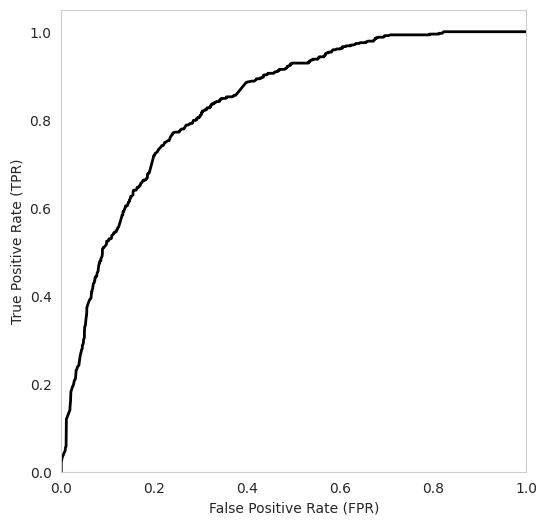

In [118]:
fpr_roc, tpr_roc, thresholds = roc_curve(churn_test_ec['Churn'], pred)

sns.set_style("whitegrid")
plt.figure(figsize=(6,6))
plt.plot(fpr_roc, tpr_roc, color='black', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.grid(False)
plt.show()

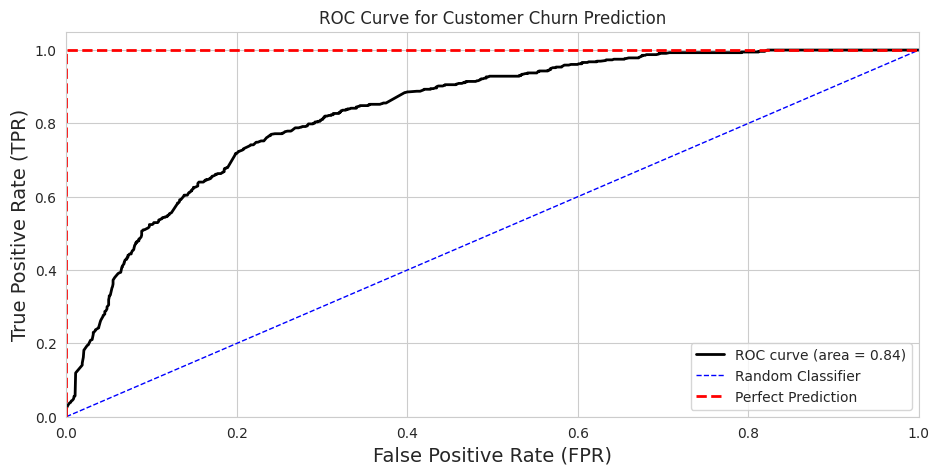

In [119]:
roc_auc = auc(fpr_roc, tpr_roc)
plt.figure(figsize=(11,5))
plt.plot(fpr_roc, tpr_roc, color='black', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='blue', lw=1, linestyle='--', label='Random Classifier')
plt.plot([0, 0, 1], [0, 1, 1], color="red", lw=2, linestyle="--", label="Perfect Prediction")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize = 14)
plt.ylabel('True Positive Rate (TPR)', fontsize = 14)
plt.title('ROC Curve for Customer Churn Prediction')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [120]:
cutoffs = [0.0, 0.10, 0.33, 0.50, 1.0]

rows = []
for c in cutoffs:
    y_pred_cutoff = (pred >= c).astype(int)
    tn, fp, fn, tp = confusion_matrix(churn_test_ec['Churn'], y_pred_cutoff).ravel()
    tpr = tp / (tp + fn) if (tp + fn) else np.nan  # sensitivity/recall
    fpr = fp / (fp + tn) if (fp + tn) else np.nan

    rows.append({
        "Cutoff": c,
        "TPR": tpr,
        "FPR": fpr,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

result = pd.DataFrame(rows).sort_values("Cutoff", ascending=False).reset_index(drop=True)
display(result.style.format({"Cutoff": "{:.2f}", "TPR": "{:.3f}", "FPR": "{:.3f}"}))

,Cutoff,TPR,FPR,TN,FP,FN,TP
0,1.00,0.000,0.000,1549,0,561,0
1,0.50,0.524,0.099,1396,153,267,294
2,0.33,0.738,0.214,1217,332,147,414
3,0.10,0.932,0.534,722,827,38,523
4,0.00,1.000,1.000,0,1549,0,561
